# CCGT Clustering — Methods (normalized 2022$ cost)

Visually, for CCGT we can see 2 groups under and above $1800/kW. This notebook tests different clustering methods — **K-Means**, **density-based** (DBSCAN), and **hierarchical** (agglomerative) — to see which one(s) actually identify these 2 groups, and whether they agree on the same split.

Uses `Cost ($/kW, 2022$)` (dollar-year-normalized, see `data_cleaning_gas.ipynb`). 

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from scipy.cluster.hierarchy import dendrogram, linkage

REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / "runreeds.py").exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent

FORECAST_DIR = REPO_ROOT / "CEPM/preprocessing/gas_capex_forecast"

df = pd.read_csv(FORECAST_DIR / "Halcyon_August_CCGT.csv")
# Use the dollar-year-normalized cost (see data_cleaning_gas.ipynb) instead of the raw, mixed-dollar-year cost
df["Cost ($/kW)"] = pd.to_numeric(df["Cost ($/kW, 2022$)"], errors="coerce")
df["Planned / Operating Year"] = pd.to_numeric(df["Planned / Operating Year"], errors="coerce")

# Same outlier cleaning as CCGT_gas_capex.ipynb
df = df[(df["Planned / Operating Year"] <= 2032) & (df["Cost ($/kW)"] <= 3000)]

X = df[["Planned / Operating Year", "Cost ($/kW)"]].values
X_scaled = StandardScaler().fit_transform(X)
df.shape

(27, 17)

## K-Means

In [2]:
X = df[["Planned / Operating Year", "Cost ($/kW)"]].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X_scaled)

# Print cluster statistics
for c in sorted(df["Cluster"].unique()):
    sub = df[df["Cluster"] == c]
    print(f"\nCluster {c} — {len(sub)} plants")
    print(f"  Year    : {sub['Planned / Operating Year'].min():.0f}–{sub['Planned / Operating Year'].max():.0f}  (mean {sub['Planned / Operating Year'].mean():.1f})")
    print(f"  Cost    : ${sub['Cost ($/kW)'].min():.0f}–${sub['Cost ($/kW)'].max():.0f} /kW  (mean ${sub['Cost ($/kW)'].mean():.0f}, std ${sub['Cost ($/kW)'].std():.0f})")


Cluster 0 — 20 plants
  Year    : 2028–2031  (mean 2029.8)
  Cost    : $1421–$2247 /kW  (mean $1954, std $219)

Cluster 1 — 7 plants
  Year    : 2026–2030  (mean 2027.4)
  Cost    : $1064–$1448 /kW  (mean $1287, std $130)


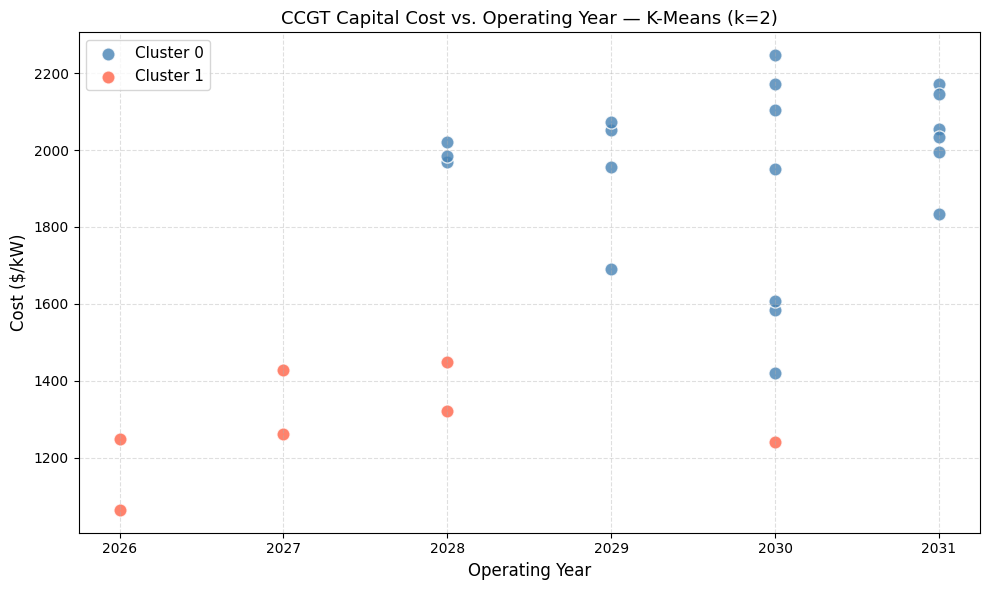

In [3]:
colors = {0: "steelblue", 1: "tomato"}
labels = {c: f"Cluster {c}" for c in sorted(df["Cluster"].unique())}

fig, ax = plt.subplots(figsize=(10, 6))

for c, grp in df.groupby("Cluster"):
    ax.scatter(grp["Planned / Operating Year"], grp["Cost ($/kW)"],
               color=colors[c], label=labels[c],
               alpha=0.8, edgecolors="white", s=90)

ax.set_xlabel("Operating Year", fontsize=12)
ax.set_ylabel("Cost ($/kW)", fontsize=12)
ax.set_title("CCGT Capital Cost vs. Operating Year — K-Means (k=2)", fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, linestyle="--", alpha=0.4)
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

K-Means (fit on standardized Year and Cost) splits the 27 plants into:
- **Cluster 0** — 20 plants, mean ~$1954/kW.
- **Cluster 1** — 7 plants, mostly earlier/cheaper projects, mean ~$1287/kW.

## Hierarchical clustering (agglomerative, Ward linkage)

Hierarchical clustering: builds a full merge tree (dendrogram) and you cut it at whatever level gives the number of clusters you want. We plot the dendrogram first, then cut it at 2 clusters to match K-Means.

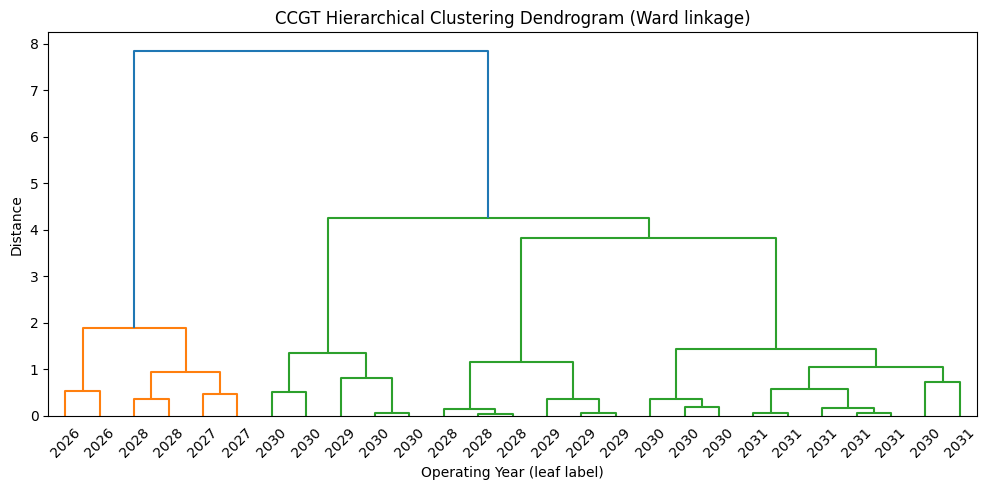

In [4]:
Z = linkage(X_scaled, method="ward")

fig, ax = plt.subplots(figsize=(10, 5))
dendrogram(Z, labels=df["Planned / Operating Year"].astype(int).values, ax=ax)
ax.set_title("CCGT Hierarchical Clustering Dendrogram (Ward linkage)")
ax.set_xlabel("Operating Year (leaf label)")
ax.set_ylabel("Distance")
plt.tight_layout()
plt.show()

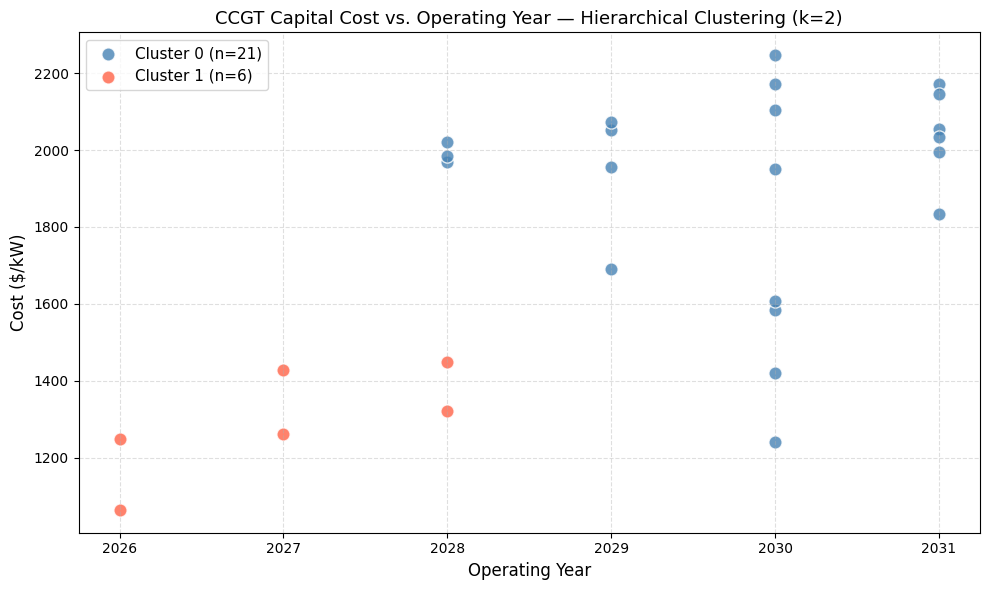

Cluster 0 — 21 plants, mean cost $1920/kW
Cluster 1 — 6 plants, mean cost $1295/kW


In [5]:
hc = AgglomerativeClustering(n_clusters=2, linkage="ward")
df["Cluster_hier"] = hc.fit_predict(X_scaled)

colors = {0: "steelblue", 1: "tomato"}
fig, ax = plt.subplots(figsize=(10, 6))
for c, grp in df.groupby("Cluster_hier"):
    ax.scatter(grp["Planned / Operating Year"], grp["Cost ($/kW)"],
               color=colors[c], label=f"Cluster {c} (n={len(grp)})",
               alpha=0.8, edgecolors="white", s=90)
ax.set_xlabel("Operating Year", fontsize=12)
ax.set_ylabel("Cost ($/kW)", fontsize=12)
ax.set_title("CCGT Capital Cost vs. Operating Year — Hierarchical Clustering (k=2)", fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, linestyle="--", alpha=0.4)
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

for c in sorted(df["Cluster_hier"].unique()):
    sub = df[df["Cluster_hier"] == c]
    print(f"Cluster {c} — {len(sub)} plants, mean cost ${sub['Cost ($/kW)'].mean():.0f}/kW")

### Other linkage criteria

`linkage` controls how the "distance" between two *clusters* is measured at each merge step:

- **single** — distance between the two **closest** points across the two clusters (nearest-neighbor). 
- **complete** — distance between the two **farthest** points across the two clusters. 
- **average** — the **mean** distance over all point pairs across the two clusters. 
- **ward** (used above) — merges whichever pair minimizes the increase in total within-cluster variance.

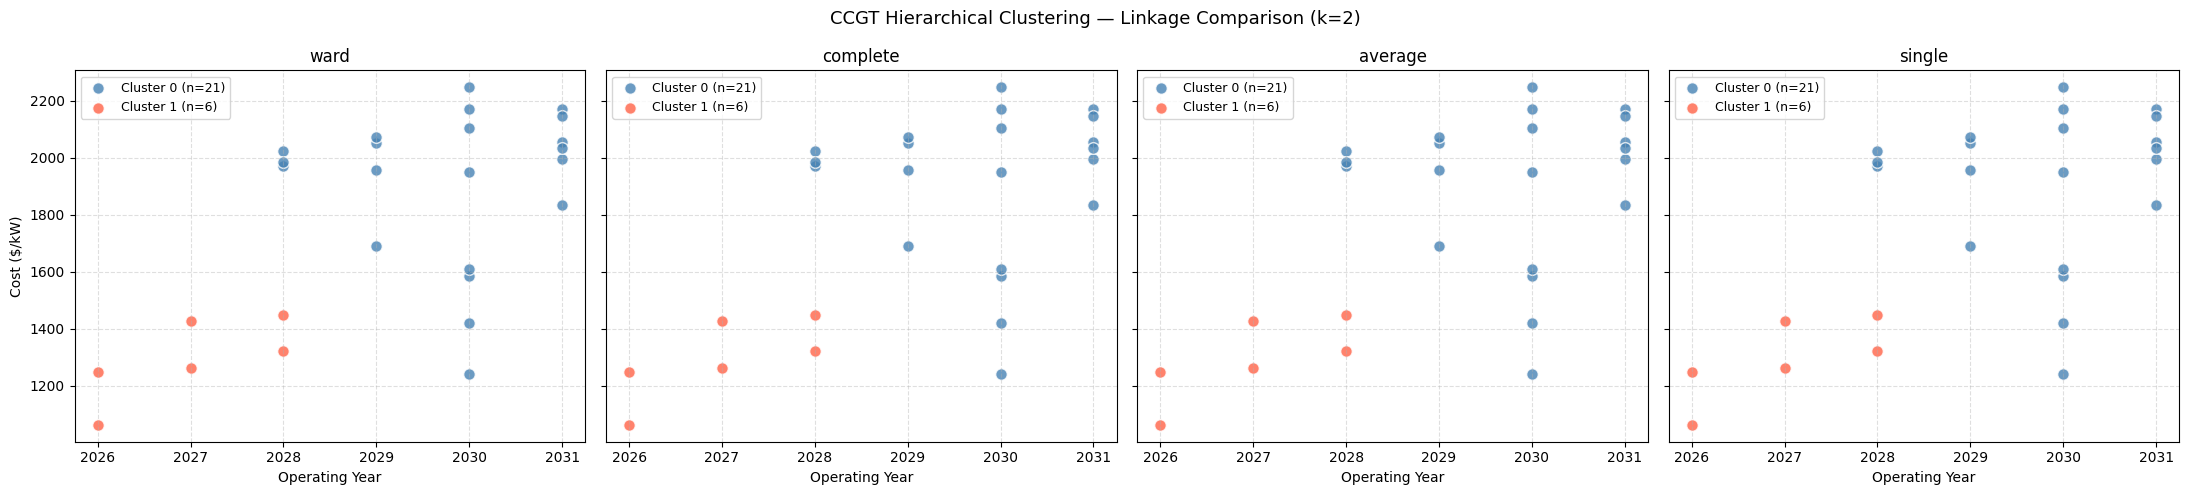

ward       counts={0: 21, 1: 6}  mean_cost={0: 1920.0, 1: 1295.0}
complete   counts={0: 21, 1: 6}  mean_cost={0: 1920.0, 1: 1295.0}
average    counts={0: 21, 1: 6}  mean_cost={0: 1920.0, 1: 1295.0}
single     counts={0: 21, 1: 6}  mean_cost={0: 1920.0, 1: 1295.0}


In [6]:
linkage_methods = ["ward", "complete", "average", "single"]
for method in linkage_methods:
    df[f"Cluster_{method}"] = AgglomerativeClustering(n_clusters=2, linkage=method).fit_predict(X_scaled)

fig, axes = plt.subplots(1, 4, figsize=(22, 5), sharey=True)
for ax, method in zip(axes, linkage_methods):
    col = f"Cluster_{method}"
    for c, grp in df.groupby(col):
        ax.scatter(grp["Planned / Operating Year"], grp["Cost ($/kW)"],
                   color=colors.get(c, "green"), label=f"Cluster {c} (n={len(grp)})",
                   alpha=0.8, edgecolors="white", s=70)
    ax.set_title(method)
    ax.set_xlabel("Operating Year")
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.legend(fontsize=9)

axes[0].set_ylabel("Cost ($/kW)")
plt.suptitle("CCGT Hierarchical Clustering — Linkage Comparison (k=2)", fontsize=13)
plt.tight_layout()
plt.show()

for method in linkage_methods:
    counts = df[f"Cluster_{method}"].value_counts().to_dict()
    means = df.groupby(f"Cluster_{method}")["Cost ($/kW)"].mean().round(0).to_dict()
    print(f"{method:10s} counts={counts}  mean_cost={means}")

**Results**: all four linkage criteria (`ward`, `complete`, `average`, `single`) now land on the exact same 21/6 split, with identical cluster means ($1920 vs $1295).

## Density-based clustering (DBSCAN)

DBSCAN groups points that are densely packed together and labels sparse points as **noise** (`-1`) instead of forcing every point into a cluster. It doesn't take a target cluster count — instead you set `eps` (neighborhood radius) and `min_samples` (minimum neighbors to form a dense region), and the number of clusters falls out of those choices.

We scan a small grid of `eps`/`min_samples` values and keep the first combination that yields exactly 2 clusters with no noise points, so the result is directly comparable to K-Means and hierarchical clustering.

In [7]:
best_params = None
for min_samples in [3, 4, 5]:
    for eps in np.arange(0.2, 1.5, 0.05):
        labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(X_scaled)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        if n_clusters == 2 and n_noise == 0:
            best_params = (eps, min_samples)
            break
    if best_params:
        break

print(f"Selected DBSCAN params: eps={best_params[0]:.2f}, min_samples={best_params[1]}")
df["Cluster_dbscan"] = DBSCAN(eps=best_params[0], min_samples=best_params[1]).fit_predict(X_scaled)

Selected DBSCAN params: eps=0.80, min_samples=3


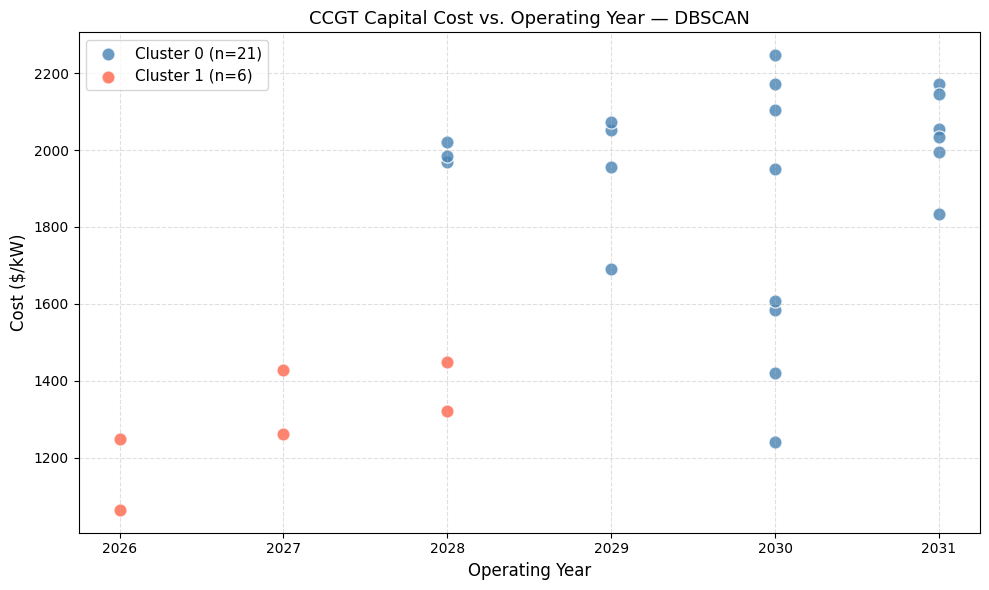

Cluster 0 — 21 plants, mean cost $1920/kW
Cluster 1 — 6 plants, mean cost $1295/kW


In [8]:
fig, ax = plt.subplots(figsize=(10, 6))
for c, grp in df.groupby("Cluster_dbscan"):
    label = "Noise" if c == -1 else f"Cluster {c} (n={len(grp)})"
    color = "gray" if c == -1 else colors[c]
    ax.scatter(grp["Planned / Operating Year"], grp["Cost ($/kW)"],
               color=color, label=label,
               alpha=0.8, edgecolors="white", s=90)
ax.set_xlabel("Operating Year", fontsize=12)
ax.set_ylabel("Cost ($/kW)", fontsize=12)
ax.set_title("CCGT Capital Cost vs. Operating Year — DBSCAN", fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, linestyle="--", alpha=0.4)
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

for c in sorted(df["Cluster_dbscan"].unique()):
    sub = df[df["Cluster_dbscan"] == c]
    label = "Noise" if c == -1 else f"Cluster {c}"
    print(f"{label} — {len(sub)} plants, mean cost ${sub['Cost ($/kW)'].mean():.0f}/kW")

DBSCAN lands on the same 21/6 split as hierarchical clustering: Cluster 0 (21 plants, mean $1920/kW) and Cluster 1 (6 plants, mean $1295/kW).

## Comparison of all methods

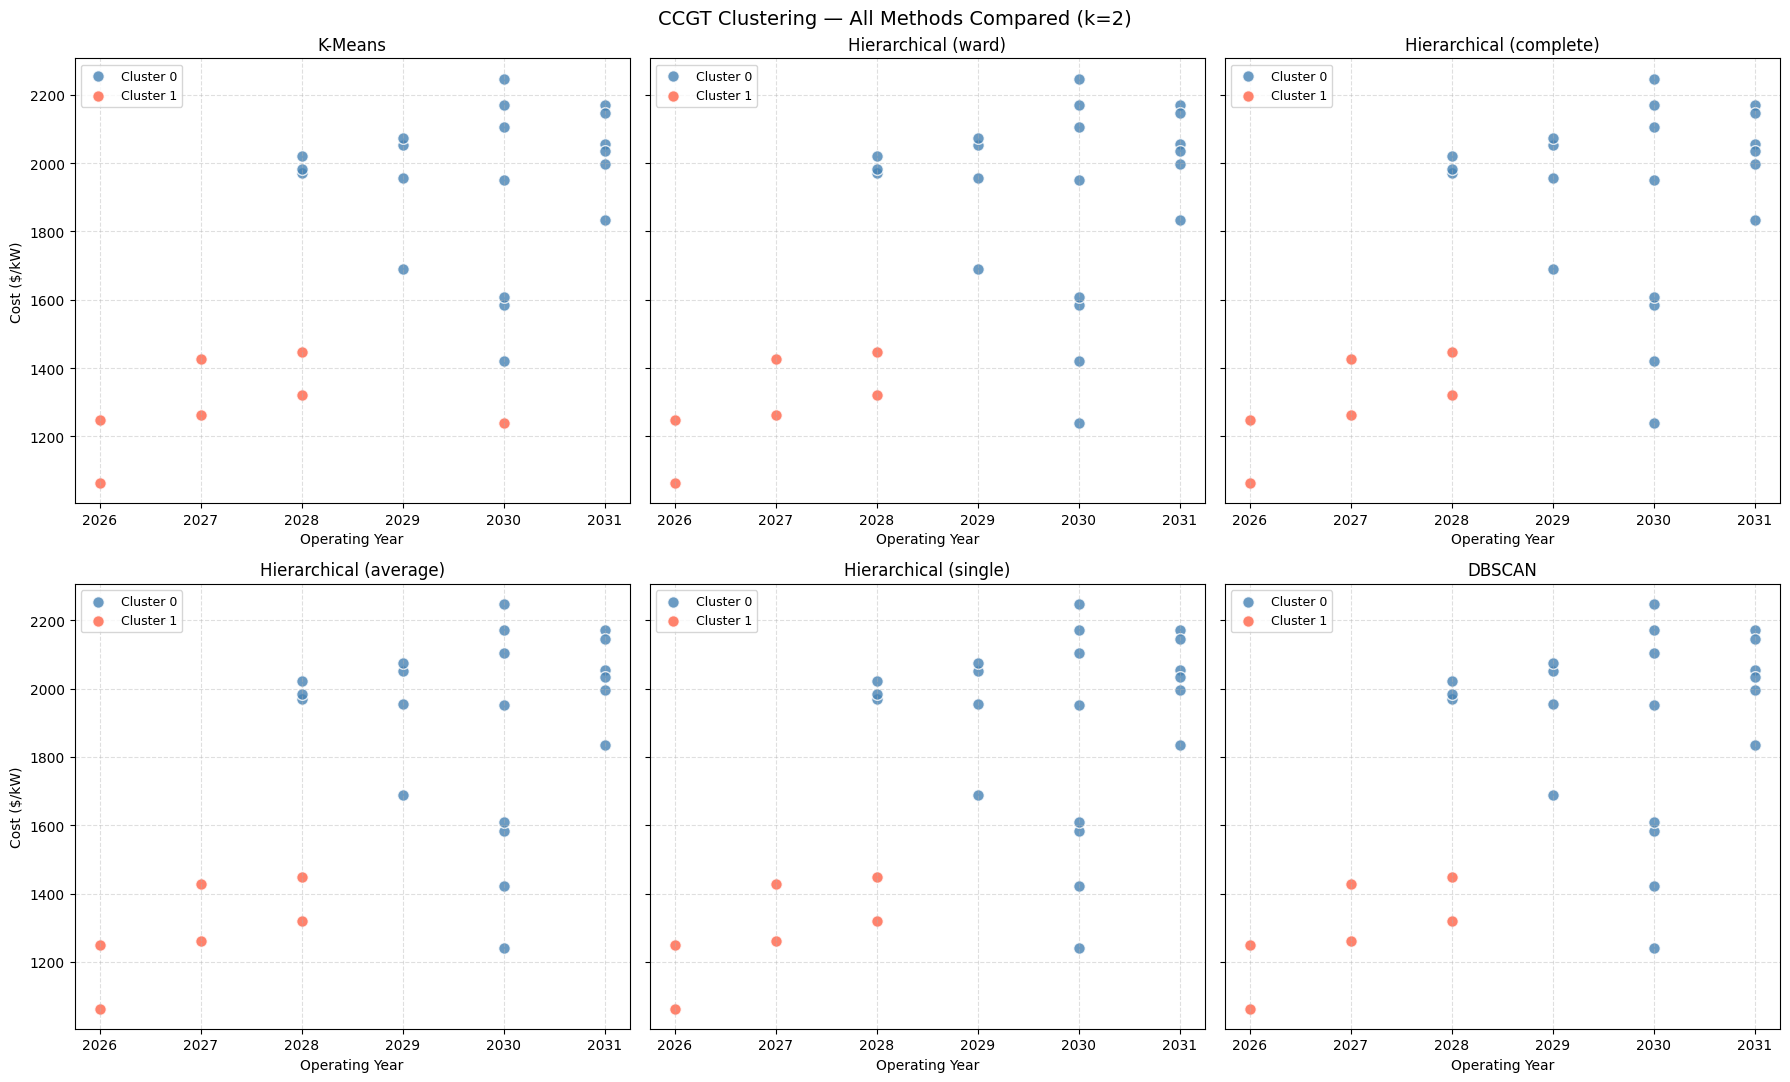

In [9]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
df["Cluster_kmeans"] = kmeans.fit_predict(X_scaled)

fig, axes = plt.subplots(2, 3, figsize=(18, 11), sharey=True)
methods = [
    ("Cluster_kmeans", "K-Means"),
    ("Cluster_ward", "Hierarchical (ward)"),
    ("Cluster_complete", "Hierarchical (complete)"),
    ("Cluster_average", "Hierarchical (average)"),
    ("Cluster_single", "Hierarchical (single)"),
    ("Cluster_dbscan", "DBSCAN"),
]

for ax, (col, title) in zip(axes.flat, methods):
    for c, grp in df.groupby(col):
        label = "Noise" if c == -1 else f"Cluster {c}"
        color = "gray" if c == -1 else colors.get(c, "green")
        ax.scatter(grp["Planned / Operating Year"], grp["Cost ($/kW)"],
                   color=color, label=label, alpha=0.8, edgecolors="white", s=70)
    ax.set_title(title)
    ax.set_xlabel("Operating Year")
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.legend(fontsize=9)

for ax in axes[:, 0]:
    ax.set_ylabel("Cost ($/kW)")
plt.suptitle("CCGT Clustering — All Methods Compared (k=2)", fontsize=14)
plt.tight_layout()
plt.show()

**Conclusion**: with normalized cost, 5 of 6 methods (all hierarchical linkages + DBSCAN) converge on the exact same 21/6 split, and K-Means is close (20/7). 

- **The split is almost entirely confounded with year**: Cluster 1 (low-cost) is only 2026-2028, Cluster 0 (high-cost) is only 2028-2031. 
- **Cluster 0 (n=21) isn't homogeneous**: within a single year it spans almost the full cost range (e.g. 2030: \$1240–\$2247/kW) — it looks more like "everything not in the small early cluster" than a coherent high-cost group.
- **Cluster 1 has only 6 points**
- **The split isn't robust to small data revisions**: when Halcyon revised a single plant's cost between the July and August trackers (Traceview, \$1326 → \$1857/kW), that one point landed right in what had been a clean gap between the two cost groups and merged them — flipping the result from an 11/16 split to 21/6. A clustering result that one data point can flip like this isn't a reliable basis for defining scenarios.

**Decision**: none of these methods give a satisfactory, robust 2-cluster split — so we don't cluster CCGT into low/high-cost scenarios. `CCGT_gas_capex.ipynb` uses a single regression on all the data instead.